In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
import joblib

# Налаштування стилю графіків
sns.set(style="whitegrid")
print("Бібліотеки успішно завантажено!")

Бібліотеки успішно завантажено!


In [5]:
print("--- Завантаження даних ---")
# Читаємо файл
df = pd.read_csv('heart_disease.csv')

# Видаляємо колонки 'id' та 'dataset', якщо вони є (вони не впливають на здоров'я)
df = df.drop(['id', 'dataset'], axis=1, errors='ignore')

# Перейменовуємо колонки на зрозумілі
# 'num' - це діагноз у вашому файлі, 'thalch' - це пульс (була помилка в назві)
df.rename(columns={'num': 'target', 'thalch': 'thalach'}, inplace=True)

# Перетворення цільової змінної у бінарний вигляд:
# У базі: 0 = здоровий, 1,2,3,4 = ступені хвороби.
# Ми робимо: 0 = здоровий, 1 = хворий (все, що більше 0)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Розмір датасету: {df.shape}")
print("Перші 5 рядків:")
display(df.head())

--- Завантаження даних ---
Розмір датасету: (920, 14)
Перші 5 рядків:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
print("--- Обробка пропусків ---")

# Визначаємо, які колонки числові, а які текстові
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Створюємо "імпутери" (заповнювачі)
num_imputer = SimpleImputer(strategy='median')        # Для чисел беремо медіану
cat_imputer = SimpleImputer(strategy='most_frequent') # Для тексту - найчастіше значення

# Заповнюємо пропуски
df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Пропуски заповнено. Перевірка на залишки NaN:")
print(df.isnull().sum().sum())  # Має бути 0

--- Обробка пропусків ---
Пропуски заповнено. Перевірка на залишки NaN:
0


In [7]:
print("--- Кодування тексту в цифри ---")

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Перетворюємо текст на числа
    df[col] = le.fit_transform(df[col].astype(str))
    # Зберігаємо "словник" (енкодер), щоб потім знати, що 0=Female, 1=Male
    label_encoders[col] = le
    print(f"Колонка '{col}' закодована. Класи: {le.classes_}")

print("\nДані готові до навчання:")
display(df.head())

--- Кодування тексту в цифри ---
Колонка 'sex' закодована. Класи: ['Female' 'Male']
Колонка 'cp' закодована. Класи: ['asymptomatic' 'atypical angina' 'non-anginal' 'typical angina']
Колонка 'fbs' закодована. Класи: ['False' 'True']
Колонка 'restecg' закодована. Класи: ['lv hypertrophy' 'normal' 'st-t abnormality']
Колонка 'exang' закодована. Класи: ['False' 'True']
Колонка 'slope' закодована. Класи: ['downsloping' 'flat' 'upsloping']
Колонка 'thal' закодована. Класи: ['fixed defect' 'normal' 'reversable defect']

Дані готові до навчання:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67.0,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,67.0,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37.0,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41.0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


C:\Users\blads\AppData\Local\Temp\ipykernel_3092\1731518508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


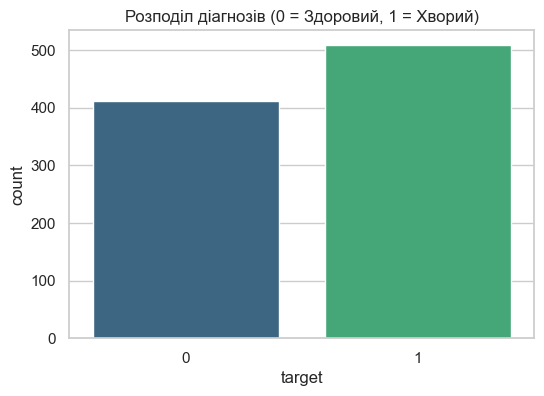

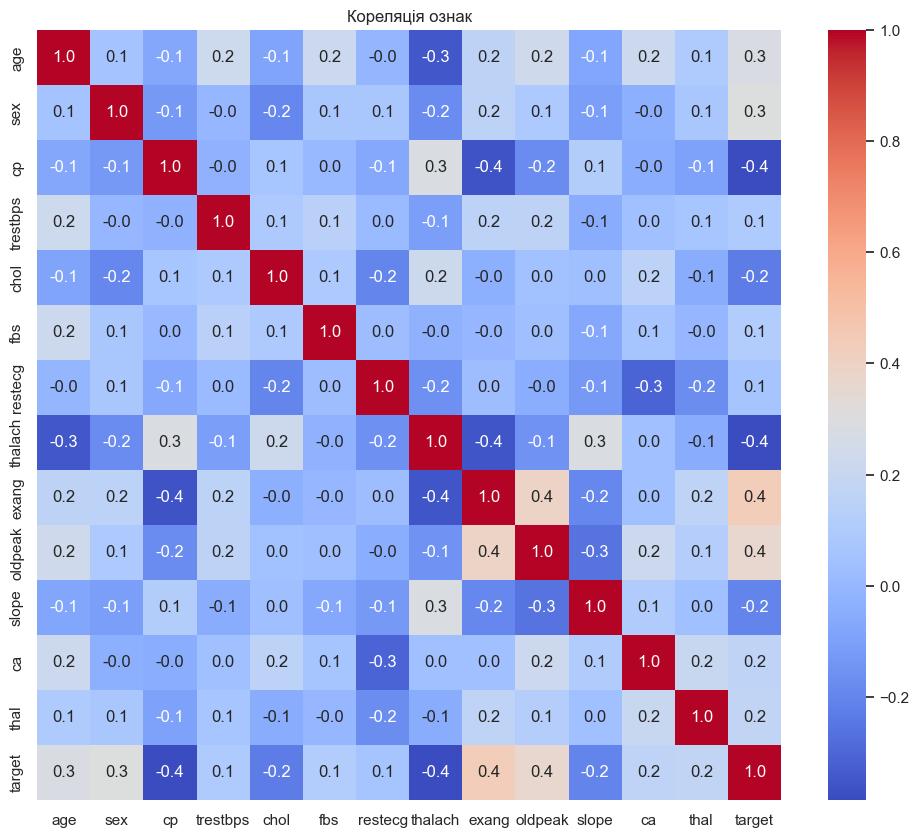

In [8]:
# Графік балансу класів
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Розподіл діагнозів (0 = Здоровий, 1 = Хворий)')
plt.show()

# Матриця кореляції
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Кореляція ознак')
plt.show()

In [9]:
# Відділяємо вхідні дані (X) від відповіді (y)
X = df.drop('target', axis=1)
y = df['target']

# Розділення train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Розмір тренувальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)

Розмір тренувальної вибірки: (736, 13)
Розмір тестової вибірки: (184, 13)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

print("--- Результати навчання ---")
best_model = None
best_recall = 0  # Будемо шукати максимальний Recall

for name, model in models.items():
    # Навчання
    model.fit(X_train_scaled, y_train)
    
    # Перевірка
    y_pred = model.predict(X_test_scaled)
    
    # Метрики
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)      # Важливо для медицини!
    roc = roc_auc_score(y_test, y_pred)
    
    print(f"\nМодель: {name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Recall:   {rec:.3f}")
    print(f"ROC-AUC:  {roc:.3f}")
    
    # Логіка вибору найкращої
    if rec > best_recall:
        best_recall = rec
        best_model = model

print(f"\n>>> Найкраща модель за метрикою Recall: {best_model}")

--- Результати навчання ---

Модель: Logistic Regression
Accuracy: 0.821
Recall:   0.843
ROC-AUC:  0.818

Модель: Random Forest
Accuracy: 0.832
Recall:   0.882
ROC-AUC:  0.825

Модель: SVM
Accuracy: 0.842
Recall:   0.882
ROC-AUC:  0.838

>>> Найкраща модель за метрикою Recall: RandomForestClassifier(random_state=42)


In [11]:
print("Збереження файлів...")

# 1. Зберігаємо модель
joblib.dump(best_model, 'heart_disease_model.pkl')

# 2. Зберігаємо скейлер (щоб правильно масштабувати нові дані)
joblib.dump(scaler, 'scaler.pkl')

# 3. Зберігаємо енкодери (щоб програма розуміла слова 'Male', 'Female')
joblib.dump(label_encoders, 'label_encoders.pkl')

# 4. Зберігаємо імп'ютери (щоб програма знала, як заповнювати пропуски)
# Це потрібно, якщо користувач залишить поле порожнім
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')

print("Успішно! Всі файли збережено у папці проекту.")

Збереження файлів...
Успішно! Всі файли збережено у папці проекту.
